In [72]:
# ============================================================
# Cell 1: Import libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ============================================================
# Cell A: Conceptual framing of this notebook
# ============================================================

## 4f Fourier CNN scattering correction as an inverse problem

This notebook studies MNIST scattering correction as a **supervised inverse problem**.

We treat the clean digit as the unknown object \(x\), the scattered measured digit as \(y\), and the learned corrector as a network that approximates the inverse mapping from \(y\) back to \(x\).

In the language of **Lecture 12**, this follows the supervised inverse-problem pipeline

$$
y_i = \left|F^{-1}\left\{F\{x_i\} \cdot e^{j\varphi}\right\}\right|^2
$$

$$
\hat{x}_i = N(y_i)
$$

where  

where

- The forward model applies a fixed phase screen $\varphi$ in the Fourier plane  
- $N(\cdot)$ is the neural network that learns to invert the scattering

This is exactly the framework shown in **Lecture 12, page 9**, where paired data, a learned network, and a reconstruction loss are used to recover the object from degraded measurements.

This notebook is also related to **deep optics**, where optics and computation are optimized together rather than separately. **Lecture 15, pages 3–4** contrast traditional imaging pipelines with deep optics systems where the optical front end can be optimized jointly with the downstream neural network.

In [73]:
# ============================================================
# Cell 2: Set random seeds for reproducibility
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# Cell B: Random initialization and reproducibility
# ============================================================

This notebook sets random seeds so that both the **phase scattering screen** and the **initial Fourier mask weights** are reproducible.

This is important because the training process learns a mapping

$$
N(y_i) \approx x_i
$$

from scattered measurements to clean images.

As described in **Lecture 12**, supervised inverse problems depend strongly on

- the training dataset
- the forward model
- the initialization of the reconstruction algorithm.

Reproducibility ensures that experiments comparing architectures, scattering strengths, or optical masks remain consistent.

In [74]:
# ============================================================
# Cell 3: Load MNIST and normalize to [0,1]
# ============================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension: (N,28,28) -> (N,28,28,1)
x_train = x_train[..., None]
x_test  = x_test[..., None]

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)
y_train shape: (60000,)
y_test shape : (10000,)


# Cell C: Clean MNIST digits as ground truth

The MNIST digits loaded in the next cell represent the **ground truth objects**

$$
x_i
$$

These images represent the true scene before any corruption or measurement noise.

During training, the correction network will attempt to reconstruct these images from scattered observations

$$
y_i
$$

using a learned reconstruction operator

$$
\hat{x}_i = N(y_i)
$$

The MNIST labels are also retained so that we can later evaluate whether the corrected images preserve the digit identity through downstream classification.

In [75]:
# ============================================================
# Cell 4: Apply phase scattering to create scattered MNIST digits
# ============================================================
# This simulates imaging through a scattering medium.
# A fixed correlated phase screen is applied in the Fourier plane.
# The detector measures intensity |U_out|^2, discarding phase.
#
# The network will learn to map:
#   scattered image  ->  clean image

def make_phase_screen(N, strength_rad, correlation_px, seed=None):
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal((N, N))
    kx = np.arange(N) - N // 2
    KX, KY = np.meshgrid(kx, kx, indexing='xy')
    sigma_k = N / (2 * np.pi * correlation_px)
    lpf = np.exp(-(KX**2 + KY**2) / (2 * sigma_k**2))
    noise_f = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(noise)))
    filtered = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(noise_f * lpf))).real
    std = filtered.std()
    if std > 0:
        filtered *= strength_rad / std
    return filtered

def apply_fixed_scattering(images, phase_screen):
    """Apply a fixed Fourier-plane phase screen to all images (vectorized)."""
    imgs = images[:, :, :, 0]
    U_f = np.fft.fft2(imgs)
    U_f_scattered = U_f * np.exp(1j * phase_screen)[np.newaxis, :, :]
    U_out = np.fft.ifft2(U_f_scattered)
    scattered = np.abs(U_out) ** 2
    max_vals = scattered.max(axis=(1, 2), keepdims=True)
    max_vals[max_vals == 0] = 1
    scattered = (scattered / max_vals).astype(np.float32)
    return scattered[:, :, :, np.newaxis]

phase_screen = make_phase_screen(28, strength_rad=2.0, correlation_px=3, seed=42)

x_train_scattered = apply_fixed_scattering(x_train, phase_screen)
x_test_scattered  = apply_fixed_scattering(x_test, phase_screen)

print("Scattered training min/max:", x_train_scattered.min(), x_train_scattered.max())
print("Scattered test min/max    :", x_test_scattered.min(), x_test_scattered.max())

Scattered training min/max: 1.9535296e-12 1.0
Scattered test min/max    : 2.148938e-11 1.0


# ============================================================
# Cell D: Phase scattering as part of the forward model
# ============================================================

To simulate a degraded imaging system, a fixed phase screen is applied in the Fourier domain to the clean MNIST digits.

This creates a forward model of the form

$$
y = \left|F^{-1}\left\{F\{x\} \cdot e^{j\varphi}\right\}\right|^2
$$

where

- \(x\) = clean image
- \(\varphi\) = fixed phase screen applied in the Fourier plane
- the intensity is measured after inverse Fourier transform.

In this experiment the phase screen scrambles the spatial-frequency content of the image, simulating optical scattering.

This forward model follows the framework used in **Lecture 12**, where inverse imaging methods attempt to recover the object \(x\) from the measurement \(y\).

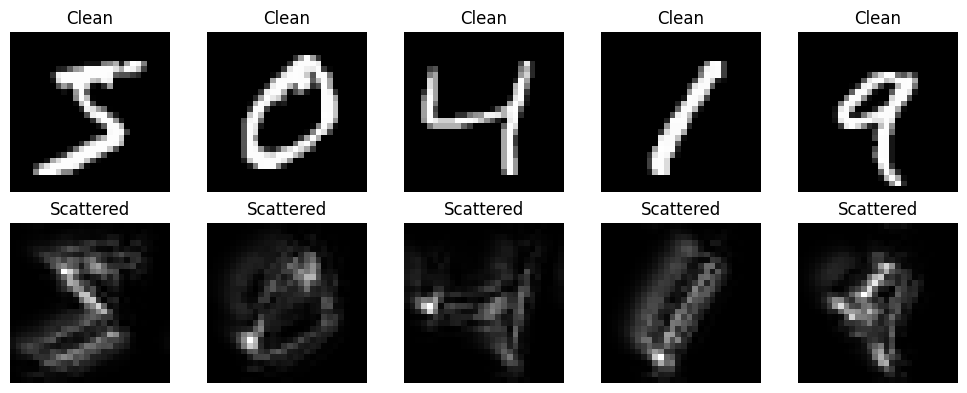

In [76]:
# ============================================================
# Cell 5: Display clean and scattered examples
# ============================================================

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i,:,:,0], cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(2,5,5+i+1)
    plt.imshow(x_train_scattered[i,:,:,0], cmap="gray")
    plt.title("Scattered")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Cell E: Visualizing clean and scattered measurements
# ============================================================

Before training the correction model, it is useful to visualize both

- the clean digits \(x\)
- the scattered measurements \(y\)

so we can understand the difficulty of the reconstruction problem.

In imaging systems, degradation often arises from blur or optical aberrations. In **Lecture 14**, blur is modeled using the **point spread function (PSF)**, which describes how a point in the scene spreads out on the sensor.

Mathematically,

$$
y = x * h
$$

where \(h\) is the PSF.

Although our experiment uses phase scattering instead of blur, both forms of degradation motivate the need for computational reconstruction methods.

In [77]:
# ============================================================
# Cell 6: Define 4f Fourier denoising layer
# ============================================================

class OpticalFourierDenoise(layers.Layer):
    """
    4f-inspired correction layer.

    Input:
        scattered image x(b,h,w,1)

    Pipeline:
        x -> complex field
          -> FFT
          -> multiply by learned Fourier-plane mask
          -> IFFT
          -> output image estimate

    The Fourier-plane mask is directly learned as:
        M = A + iB

    with A and B initialized using RandomNormal(stddev=0.02),
    matching the FCNN-style initialization.

    This is NOT using an LG basis.
    """

    def __init__(self, filters, input_height, input_width,
                 phase_only=True, use_intensity=False, use_I2=False,
                 eps=1e-6, **kwargs):
        super().__init__(**kwargs)

        self.filters = filters
        self.H = input_height
        self.W = input_width
        self.phase_only = phase_only
        self.use_intensity = use_intensity
        self.use_I2 = use_I2
        self.eps = eps

    def build(self, input_shape):
        self.in_channels = int(input_shape[-1])

        self.kernel_real = self.add_weight(
            name="kernel_real",
            shape=(self.in_channels, self.filters, self.H, self.W),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
            dtype=tf.float32
        )

        self.kernel_imag = self.add_weight(
            name="kernel_imag",
            shape=(self.in_channels, self.filters, self.H, self.W),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
            dtype=tf.float32
        )

    def call(self, inputs):
        # -------------------------------------------------
        # Step 1: Convert input to complex field
        # -------------------------------------------------
        x = tf.cast(inputs, tf.complex64)              # (B,H,W,C)
        x = tf.transpose(x, perm=[0,3,1,2])            # (B,C,H,W)

        # -------------------------------------------------
        # Step 2: FFT -> Fourier plane
        # -------------------------------------------------
        Uf = tf.signal.fft2d(x)                        # (B,C,H,W)

        # -------------------------------------------------
        # Step 3: Build complex learned masks
        # -------------------------------------------------
        mask = tf.complex(self.kernel_real, self.kernel_imag)   # (C,F,H,W)

        power = tf.reduce_mean(tf.abs(mask)**2, axis=[2,3], keepdims=True)
        mask = mask / tf.cast(tf.sqrt(power + self.eps), tf.complex64)

        # Optional phase-only projection
        if self.phase_only:
            phase = tf.math.angle(mask)
            mask = tf.exp(1j * tf.cast(phase, tf.complex64))

        # -------------------------------------------------
        # Step 4: Apply learned mask in Fourier plane
        # -------------------------------------------------
        Uf = Uf[:, :, None, :, :]          # (B,C,1,H,W)
        mask = mask[None, :, :, :, :]      # (1,C,F,H,W)

        Uf_filt = Uf * mask                # (B,C,F,H,W)

        # Sum over input channels
        Uf_filt = tf.reduce_sum(Uf_filt, axis=1)   # (B,F,H,W)

        # -------------------------------------------------
        # Step 5: IFFT -> image plane
        # -------------------------------------------------
        u_out = tf.signal.ifft2d(Uf_filt)          # (B,F,H,W)

        # -------------------------------------------------
        # Step 6: Detection / output formation
        # -------------------------------------------------
        if self.use_intensity:
            y = tf.abs(u_out)**2
            if self.use_I2:
                y = y**2
        else:
            # Better for denoising regression:
            # allow signed/real reconstruction rather than intensity only
            y = tf.math.real(u_out)

        # -------------------------------------------------
        # Step 7: Return channels-last
        # -------------------------------------------------
        y = tf.transpose(tf.cast(y, tf.float32), perm=[0,2,3,1])   # (B,H,W,F)
        return y

# ============================================================
# Cell F: Optical interpretation of the Fourier layer
# ============================================================

The custom layer implemented in this notebook simulates a **4f optical system**.

A classical 4f system performs the transformation

$$
U_f(f_x,f_y) = F\{u(x,y)\}
$$

followed by multiplication with a Fourier-plane mask

$$
U_{filtered}(f_x,f_y) =
U_f(f_x,f_y) \cdot H(f_x,f_y)
$$

and reconstruction through the inverse transform

$$
u_{out}(x,y) =
F^{-1}
\left[
U_{filtered}(f_x,f_y)
\right]
$$

This pipeline corresponds directly to the **wave-optics model shown in Lecture 15**, where an optical element modifies the wavefront before propagation to a sensor.

In [78]:
# ============================================================
# Cell 7: Build denoising 4f model
# ============================================================

model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    OpticalFourierDenoise(
        filters=1,
        input_height=28,
        input_width=28,
        phase_only=True,
        use_intensity=False,
        use_I2=True
    )
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ optical_fourier_denoise_4       │ (None, 28, 28, 1)      │         1,568 │
│ (OpticalFourierDenoise)         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568 (6.12 KB)

 Trainable params: 1,568 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

# ============================================================
# Cell G: Hybrid optical–computational reconstruction
# ============================================================

The full model combines

- a **trainable Fourier optical layer**
- conventional convolutional layers
- a reconstruction output layer.

This creates a hybrid system

$$
x \rightarrow
\text{Optical Layer}
\rightarrow
\text{CNN}
\rightarrow
\hat{x}
$$

which is an example of **deep optics**.

In **Lecture 15**, deep optics refers to systems where both the optical element and the computational processing are optimized together in a single learning framework.

In [79]:
# ============================================================
# Cell 8: Compile model for denoising
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

# ============================================================
# Cell H: Reconstruction loss
# ============================================================

The model is trained using **mean squared error (MSE)**.

The loss function is

$$
L(x_i,\hat{x}_i) =
\frac{1}{N}
\sum
(x_i - \hat{x}_i)^2
$$

where

- $x_i$ = ground truth clean image
- $\hat{x}_i$ is the reconstructed image

This is the same reconstruction loss shown in **Lecture 12, page 10**, where supervised neural networks learn the inverse mapping from measurements to objects.

In [80]:
# ============================================================
# Cell 9: Train the denoising model
# ============================================================

history = model.fit(
    x_train_scattered, x_train,
    validation_data=(x_test_scattered, x_test),
    epochs=5,
    batch_size=64
)

Epoch 1/5


938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0516 - mae: 0.1169 - val_loss: 0.0502 - val_mae: 0.1151
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0494 - mae: 0.1141 - val_loss: 0.0502 - val_mae: 0.1151
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0494 - mae: 0.1141 - val_loss: 0.0502 - val_mae: 0.1151
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0494 - mae: 0.1141 - val_loss: 0.0502 - val_mae: 0.1150
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0494 - mae: 0.1141 - val_loss: 0.0502 - val_mae: 0.1150


# ============================================================
# Cell I: Physical interpretation of training
# ============================================================

During training the model learns the optimal Fourier-plane mask

$$
H(f_x,f_y)
$$

that corrects scattering artifacts while preserving useful spatial frequencies.

The learned optical transformation becomes

$$
u_{out}(x,y) =
F^{-1}
\left[
F(x) H(f_x,f_y)
\right]
$$

This means the model is effectively learning a **data-driven optical filter**.

In **Lecture 14**, the aperture determines the shape of the blur kernel. In this notebook, the Fourier mask plays a similar role but is optimized automatically through gradient descent.

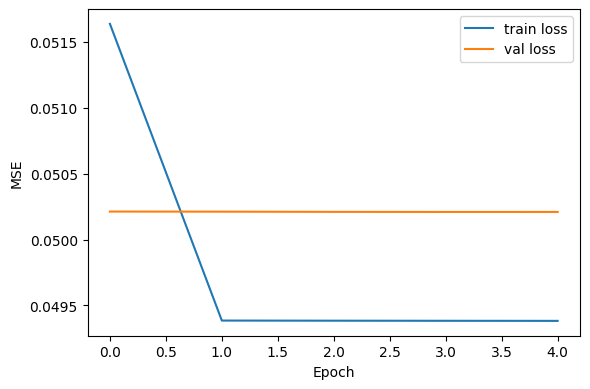

In [81]:
# ============================================================
# Cell 10: Plot training history
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Cell J: Interpreting training curves
# ============================================================

Training curves plot the reconstruction loss over epochs.

Ideally we observe

$$
L_{train} \downarrow
\quad
L_{val} \downarrow
$$

indicating that the learned mapping

$$
\hat{x} = N(y)
$$

is improving.

These curves provide evidence that the model is successfully learning the inverse operator described in **Lecture 12**.

In [82]:
# ============================================================
# Cell 11: Predict corrected images
# ============================================================

x_test_corrected = model.predict(x_test_scattered)

print("Corrected shape:", x_test_corrected.shape)
print("Min:", x_test_corrected.min())
print("Max:", x_test_corrected.max())
print("Mean:", x_test_corrected.mean())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Corrected shape: (10000, 28, 28, 1)
Min: -0.37434515
Max: 1.120527
Mean: 0.07343718


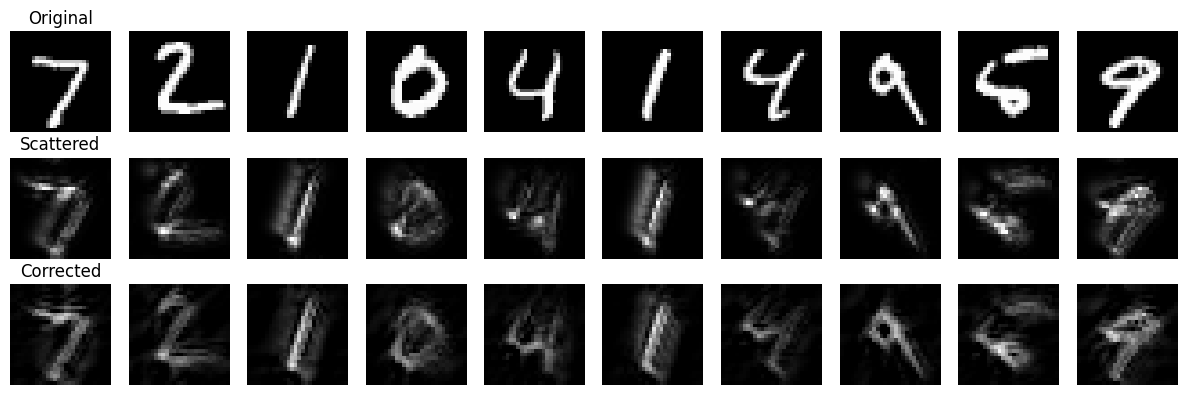

In [83]:
# ============================================================
# Cell 12: Plot original, scattered, and corrected images
# ============================================================

def plot_images(original, scattered, corrected, n=10):

    plt.figure(figsize=(12,4))

    for i in range(n):

        # Original
        plt.subplot(3,n,i+1)
        plt.imshow(original[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Original")

        # Scattered
        plt.subplot(3,n,i+1+n)
        plt.imshow(scattered[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Scattered")

        # Corrected
        plt.subplot(3,n,i+1+2*n)
        plt.imshow(corrected[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Corrected")

    plt.tight_layout()
    plt.show()


plot_images(x_test, x_test_scattered, x_test_corrected, n=10)

# Cell M: Classification-based evaluation of the 4f corrector

Pixel-space reconstruction quality does not always tell us whether digit identity is preserved.

To evaluate that, we train a classifier on clean MNIST and test it on:

1. clean MNIST
2. scattered MNIST
3. corrected MNIST obtained from the 4f FCNN

Because the FCNN corrector outputs multiple channels, we convert its output to a single grayscale image by averaging across channels before passing it to the classifier.

In [84]:
# ============================================================
# Cell 14: Define a CNN classifier for MNIST
# ============================================================
# This classifier is trained only on clean MNIST.
# Then we test it on clean, scattered, and corrected inputs.

def build_classifier():
    inp = Input(shape=(28, 28, 1))

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(10, activation="softmax")(x)

    clf = Model(inp, out)
    clf.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return clf

classifier = build_classifier()
classifier.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# ============================================================
# Cell 15: Train classifier on clean MNIST
# ============================================================

clf_history = classifier.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 139ms/step - accuracy: 0.9320 - loss: 0.2276 - val_accuracy: 0.9786 - val_loss: 0.0664
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 144ms/step - accuracy: 0.9824 - loss: 0.0580 - val_accuracy: 0.9838 - val_loss: 0.0511
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 134ms/step - accuracy: 0.9877 - loss: 0.0415 - val_accuracy: 0.9845 - val_loss: 0.0518
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 137ms/step - accuracy: 0.9904 - loss: 0.0325 - val_accuracy: 0.9857 - val_loss: 0.0445
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.9925 - loss: 0.0255 - val_accuracy: 0.9883 - val_loss: 0.0377


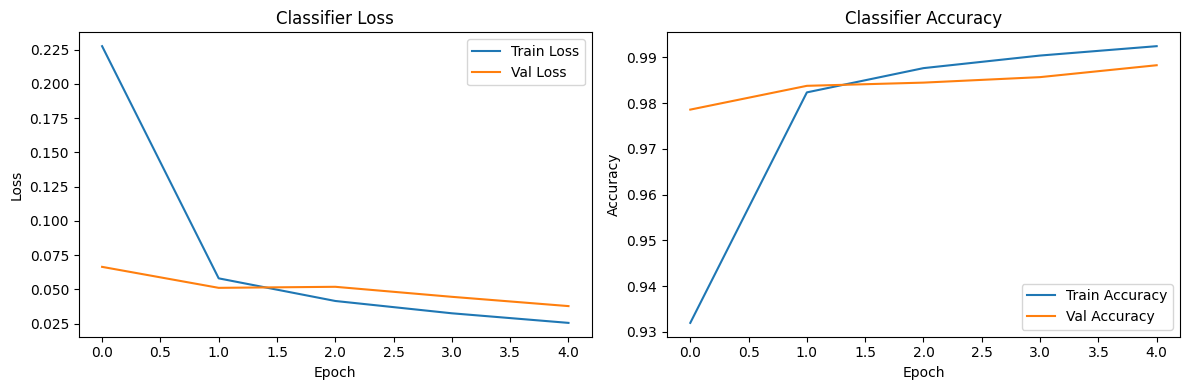

In [86]:
# ============================================================
# Cell 16: Plot classifier training history
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(clf_history.history["loss"], label="Train Loss")
plt.plot(clf_history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clf_history.history["accuracy"], label="Train Accuracy")
plt.plot(clf_history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# Cell 17: Evaluate classifier on clean, scattered, corrected MNIST
# ============================================================

clean_loss, clean_acc = classifier.evaluate(x_test, y_test, verbose=0)
scattered_loss, scattered_acc = classifier.evaluate(x_test_scattered, y_test, verbose=0)
cor_loss, cor_acc = classifier.evaluate(x_test_corrected, y_test, verbose=0)

print(f"Clean accuracy     : {clean_acc:.4f}")
print(f"Scattered accuracy : {scattered_acc:.4f}")
print(f"Corrected accuracy : {cor_acc:.4f}")

Clean accuracy     : 0.9883
Scattered accuracy : 0.6277
Corrected accuracy : 0.9059


In [88]:
# ============================================================
# Cell 18: Generate class predictions
# ============================================================

y_pred_clean = np.argmax(classifier.predict(x_test), axis=1)
y_pred_scattered = np.argmax(classifier.predict(x_test_scattered), axis=1)
y_pred_corrected = np.argmax(classifier.predict(x_test_corrected), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


In [89]:
# ============================================================
# Cell 19: Print classification reports
# ============================================================

print("Classification report: CLEAN")
print(classification_report(y_test, y_pred_clean))

print("\nClassification report: SCATTERED")
print(classification_report(y_test, y_pred_scattered))

print("\nClassification report: CORRECTED")
print(classification_report(y_test, y_pred_corrected))

Classification report: CLEAN
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.97      1.00      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Classification report: SCATTERED
              precision    recall  f1-score   support

           0       0.96      0.20      0.34       980
           1       0.82      0.76      0.79      1135
           2   

In [90]:
# ============================================================
# Cell 20: Compute confusion matrices
# ============================================================

cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_scattered = confusion_matrix(y_test, y_pred_scattered)
cm_corrected = confusion_matrix(y_test, y_pred_corrected)

print("Confusion matrix: CLEAN")
print(cm_clean)

print("\nConfusion matrix: SCATTERED")
print(cm_scattered)

print("\nConfusion matrix: CORRECTED")
print(cm_corrected)

Confusion matrix: CLEAN
[[ 971    0    2    0    0    2    1    2    2    0]
 [   0 1130    4    0    0    0    0    1    0    0]
 [   1    0 1026    0    0    0    0    5    0    0]
 [   0    0    2  998    0   10    0    0    0    0]
 [   0    1    0    0  965    0    1    0    3   12]
 [   0    0    0    1    0  890    1    0    0    0]
 [   1    1    0    1    1    6  947    0    1    0]
 [   0    1    8    0    0    1    0 1016    1    1]
 [   2    1    5    2    0    4    2    6  949    3]
 [   0    1    1    0    1    5    0    6    4  991]]

Confusion matrix: SCATTERED
[[200  86  87  46   1 439   2   1  92  26]
 [  0 858  18  10   0   8  86  12 137   6]
 [  0  34 810 129   1  38   5   3  10   2]
 [  0  11  27 734   0 191   0   7   7  33]
 [  2  14  86   0 616 129  29  24  57  25]
 [  0   0   6  35   0 813   1  11  15  11]
 [  1   8  40  11  10 203 668   0  15   2]
 [  3  14  44  53   2  34   0 778  13  87]
 [  2  15  14  11   1 551   2   9 353  16]
 [  1   2   8  12 205 151   3

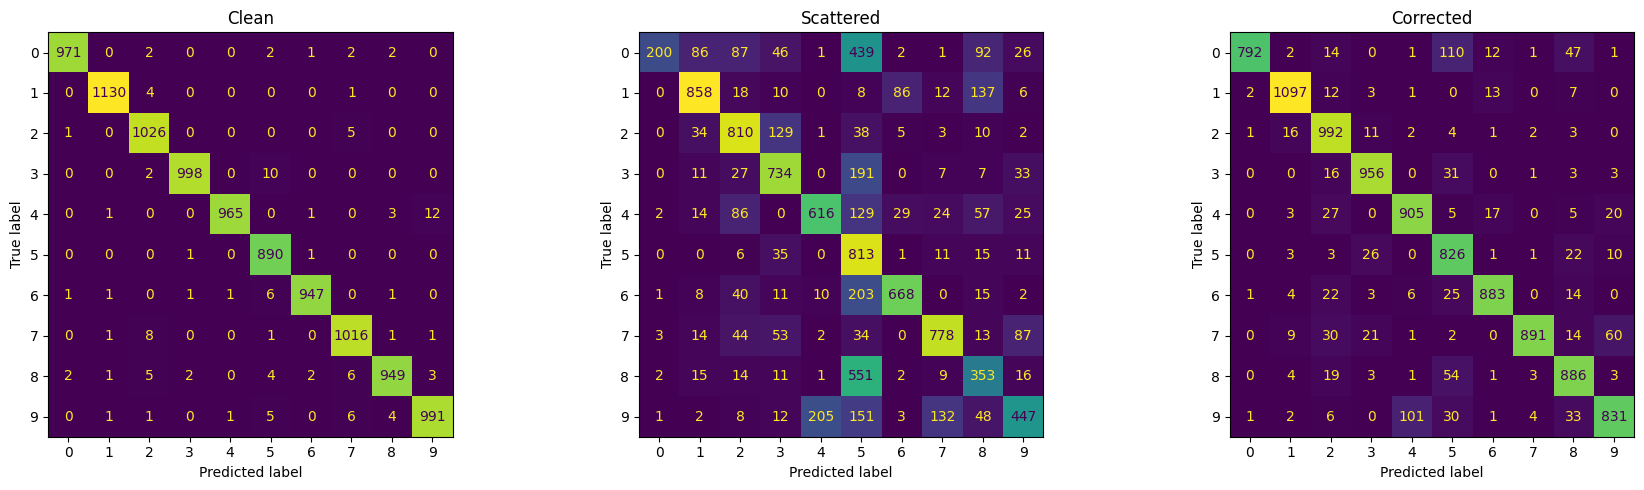

In [91]:
# ============================================================
# Cell 21: Plot confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Clean")

ConfusionMatrixDisplay(cm_scattered).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Scattered")

ConfusionMatrixDisplay(cm_corrected).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Corrected")

plt.tight_layout()
plt.show()

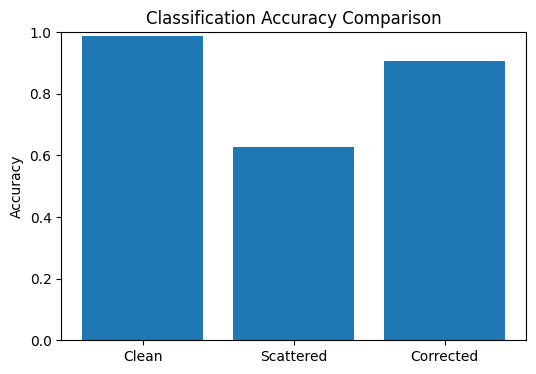

Clean: 0.9883
Scattered: 0.6277
Corrected: 0.9059


In [92]:
# ============================================================
# Cell 22: Compare classification accuracy
# ============================================================

conditions = ["Clean", "Scattered", "Corrected"]
accuracies = [clean_acc, scattered_acc, cor_acc]

plt.figure(figsize=(6, 4))
plt.bar(conditions, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Comparison")
plt.show()

for name, acc in zip(conditions, accuracies):
    print(f"{name}: {acc:.4f}")

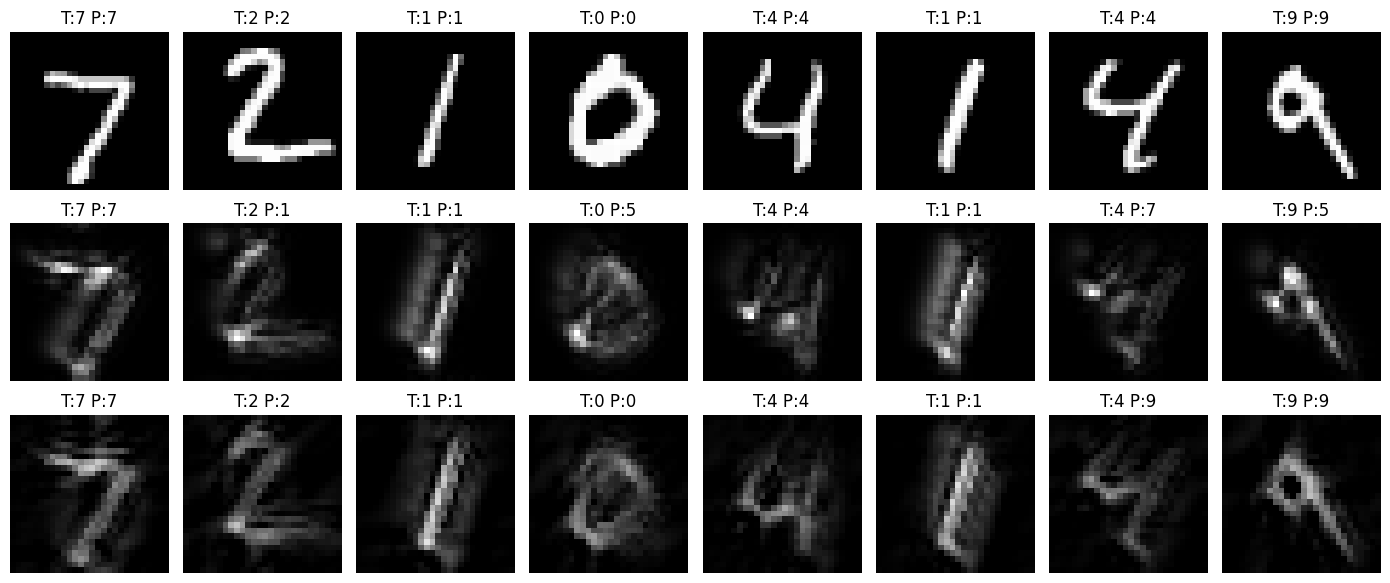

In [93]:
# ============================================================
# Cell 23: Show predictions for clean, scattered, corrected images
# ============================================================

n = 8
plt.figure(figsize=(14, 6))

for i in range(n):
    # Clean
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_clean[i]}")
    plt.axis("off")

    # Scattered
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_scattered[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_scattered[i]}")
    plt.axis("off")

    # Corrected
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_corrected[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_corrected[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()